In [ ]:
# Step 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Step 2

import pandas as pd

df = pd.read_csv("student_spending (1).csv")
df.head()

,Unnamed: 0,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,188,41,78,134,127,72,Credit/Debit Card
1,1,24,Female,Junior,Economics,1006,875,4908,557,365,85,252,74,92,226,129,68,Credit/Debit Card
2,2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,99,130,23,239,112,133,Cash
3,3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,223,99,30,163,105,55,Mobile Payment App
4,4,20,Female,Senior,Computer Science,810,522,3887,825,372,168,194,48,71,88,71,104,Credit/Debit Card


In [ ]:
# Step 3

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

# Drop the unnecessary index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("\nUpdated shape:", df.shape)
df.head()

Shape: (1000, 18)

Columns:
Index(['Unnamed: 0', 'age', 'gender', 'year_in_school', 'major',
       'monthly_income', 'financial_aid', 'tuition', 'housing', 'food',
       'transportation', 'books_supplies', 'entertainment', 'personal_care',
       'technology', 'health_wellness', 'miscellaneous',
       'preferred_payment_method'],
      dtype='object')

Missing values:
Unnamed: 0                  0
age                         0
gender                      0
year_in_school              0
major                       0
monthly_income              0
financial_aid               0
tuition                     0
housing                     0
food                        0
transportation              0
books_supplies              0
entertainment               0
personal_care               0
technology                  0
health_wellness             0
miscellaneous               0
preferred_payment_method    0
dtype: int64

Updated shape: (1000, 17)


,age,gender,year_in_school,major,monthly_income,financial_aid,tuition,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous,preferred_payment_method
0,19,Non-binary,Freshman,Psychology,958,270,5939,709,296,123,188,41,78,134,127,72,Credit/Debit Card
1,24,Female,Junior,Economics,1006,875,4908,557,365,85,252,74,92,226,129,68,Credit/Debit Card
2,24,Non-binary,Junior,Economics,734,928,3051,666,220,137,99,130,23,239,112,133,Cash
3,23,Female,Senior,Computer Science,617,265,4935,652,289,114,223,99,30,163,105,55,Mobile Payment App
4,20,Female,Senior,Computer Science,810,522,3887,825,372,168,194,48,71,88,71,104,Credit/Debit Card


In [ ]:
# Step 4

df['total_spending'] = (
    df['housing'] +
    df['food'] +
    df['transportation'] +
    df['books_supplies'] +
    df['entertainment'] +
    df['personal_care'] +
    df['technology'] +
    df['health_wellness'] +
    df['miscellaneous']
)

df['total_funds'] = df['monthly_income'] + df['financial_aid']
df['leftover_money'] = df['total_funds'] - df['total_spending']

print(df[['monthly_income', 'financial_aid', 'total_spending', 'total_funds', 'leftover_money']].head())

print("\nSummary statistics:")
print(df[['total_spending', 'total_funds', 'leftover_money']].describe())

   monthly_income  financial_aid  total_spending  total_funds  leftover_money
0             958            270            1768         1228            -540
1            1006            875            1848         1881              33
2             734            928            1759         1662             -97
3             617            265            1730          882            -848
4             810            522            1941         1332            -609

Summary statistics:
       total_spending  total_funds  leftover_money
count      1000.00000  1000.000000     1000.000000
mean       1795.08300  1525.421000     -269.662000
std         238.49789   418.348868      481.329933
min        1055.00000   560.000000    -1547.000000
25%        1622.00000  1227.750000     -607.000000
50%        1784.00000  1520.000000     -276.000000
75%        1968.50000  1843.500000       62.500000
max        2453.00000  2495.000000     1034.000000


In [ ]:
# Step 5

df['financial_stress'] = np.where(df['leftover_money'] < 0, 1, 0)

print(df[['leftover_money', 'financial_stress']].head())

print("\nClass counts:")
print(df['financial_stress'].value_counts())

print("\nClass percentages:")
print(df['financial_stress'].value_counts(normalize=True) * 100)

   leftover_money  financial_stress
0            -540                 1
1              33                 0
2             -97                 1
3            -848                 1
4            -609                 1

Class counts:
financial_stress
1    705
0    295
Name: count, dtype: int64

Class percentages:
financial_stress
1    70.5
0    29.5
Name: proportion, dtype: float64


In [ ]:
# Step 6

print("Average leftover money by stress group:")
print(df.groupby('financial_stress')['leftover_money'].mean())

print("\nAverage total spending by stress group:")
print(df.groupby('financial_stress')['total_spending'].mean())

print("\nAverage total funds by stress group:")
print(df.groupby('financial_stress')['total_funds'].mean())

print("\nStress rate:")
print(df['financial_stress'].mean())

Average leftover money by stress group:
financial_stress
0    303.708475
1   -509.582979
Name: leftover_money, dtype: float64

Average total spending by stress group:
financial_stress
0    1665.311864
1    1849.384397
Name: total_spending, dtype: float64

Average total funds by stress group:
financial_stress
0    1969.020339
1    1339.801418
Name: total_funds, dtype: float64

Stress rate:
0.705


In [ ]:
# Step 7

features = [
    'monthly_income',
    'financial_aid',
    'housing',
    'food',
    'transportation',
    'books_supplies',
    'entertainment',
    'personal_care',
    'technology',
    'health_wellness',
    'miscellaneous'
]

X = df[features]
y = df['financial_stress']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (1000, 11)
Target shape: (1000,)


,monthly_income,financial_aid,housing,food,transportation,books_supplies,entertainment,personal_care,technology,health_wellness,miscellaneous
0,958,270,709,296,123,188,41,78,134,127,72
1,1006,875,557,365,85,252,74,92,226,129,68
2,734,928,666,220,137,99,130,23,239,112,133
3,617,265,652,289,114,223,99,30,163,105,55
4,810,522,825,372,168,194,48,71,88,71,104


In [ ]:
# Step 8

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 11)
X_test shape: (200, 11)
y_train shape: (800,)
y_test shape: (200,)


In [ ]:
# Step 9

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (800, 11)
Scaled testing data shape: (200, 11)


In [ ]:
# Step 10

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [ ]:
# Step 11

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
ROC AUC: 1.0

Confusion Matrix:
[[ 59   0]
 [  0 141]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        59
           1       1.00      1.00      1.00       141

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
# Step 12

coef_df = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
})

coef_df = coef_df.sort_values(by='coefficient', ascending=False)
print(coef_df)

            feature  coefficient
2           housing     2.689975
3              food     1.450794
8        technology     1.210961
5    books_supplies     1.048098
10    miscellaneous     0.823851
4    transportation     0.728524
9   health_wellness     0.633129
6     entertainment     0.443112
7     personal_care     0.380786
1     financial_aid    -4.529575
0    monthly_income    -4.844722


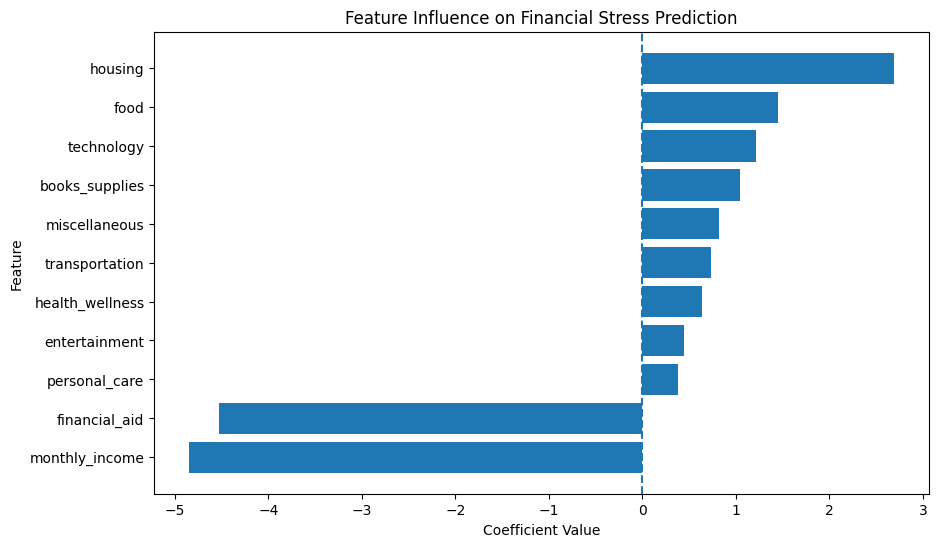

In [ ]:
# Step 13

coef_df = coef_df.sort_values(by='coefficient')

plt.figure(figsize=(10, 6))
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Influence on Financial Stress Prediction")
plt.axvline(x=0, linestyle='--')
plt.show()

In [ ]:
# Step 14

def predict_financial_stress(monthly_income, financial_aid, housing, food, transportation,
                             books_supplies, entertainment, personal_care,
                             technology, health_wellness, miscellaneous):

    input_data = pd.DataFrame([{
        'monthly_income': monthly_income,
        'financial_aid': financial_aid,
        'housing': housing,
        'food': food,
        'transportation': transportation,
        'books_supplies': books_supplies,
        'entertainment': entertainment,
        'personal_care': personal_care,
        'technology': technology,
        'health_wellness': health_wellness,
        'miscellaneous': miscellaneous
    }])

    input_scaled = scaler.transform(input_data)
    stress_probability = model.predict_proba(input_scaled)[0][1]
    stress_prediction = model.predict(input_scaled)[0]

    return {
        "predicted_class": int(stress_prediction),
        "stress_probability": round(float(stress_probability), 4)
    }

print("Simulator function created successfully.")

Simulator function created successfully.


In [ ]:
# Step 15

result = predict_financial_stress(
    monthly_income=1200,
    financial_aid=300,
    housing=900,
    food=250,
    transportation=120,
    books_supplies=80,
    entertainment=150,
    personal_care=60,
    technology=100,
    health_wellness=70,
    miscellaneous=90
)

print(result)

{'predicted_class': 1, 'stress_probability': 0.9925}


In [ ]:
# Step 16

entertainment_values = [50, 100, 150, 200, 250, 300]
results = []

for ent in entertainment_values:
    result = predict_financial_stress(
        monthly_income=1200,
        financial_aid=300,
        housing=900,
        food=250,
        transportation=120,
        books_supplies=80,
        entertainment=ent,
        personal_care=60,
        technology=100,
        health_wellness=70,
        miscellaneous=90
    )

    results.append({
        'entertainment': ent,
        'stress_probability': result['stress_probability']
    })

simulation_df = pd.DataFrame(results)
print(simulation_df)

   entertainment  stress_probability
0             50              0.9763
1            100              0.9866
2            150              0.9925
3            200              0.9958
4            250              0.9976
5            300              0.9987


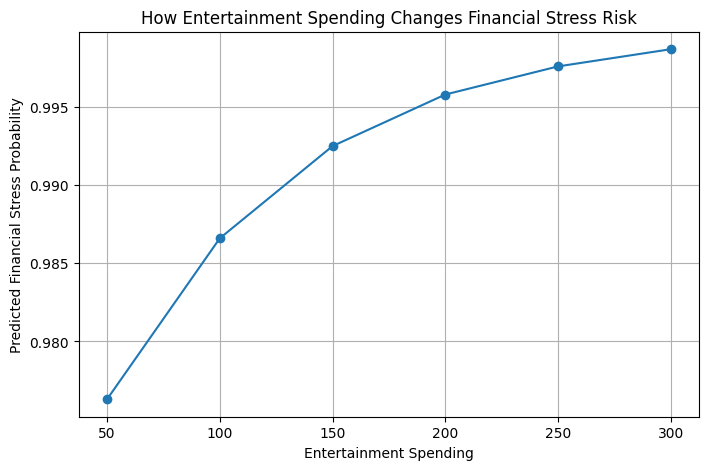

In [ ]:
# Step 17

plt.figure(figsize=(8, 5))
plt.plot(simulation_df['entertainment'], simulation_df['stress_probability'], marker='o')
plt.xlabel("Entertainment Spending")
plt.ylabel("Predicted Financial Stress Probability")
plt.title("How Entertainment Spending Changes Financial Stress Risk")
plt.grid(True)
plt.show()

In [ ]:
# Step 18

shock_scenarios = [
    {
        'scenario': 'Baseline',
        'monthly_income': 1200,
        'financial_aid': 300,
        'housing': 900,
        'food': 250,
        'transportation': 120,
        'books_supplies': 80,
        'entertainment': 150,
        'personal_care': 60,
        'technology': 100,
        'health_wellness': 70,
        'miscellaneous': 90
    },
    {
        'scenario': 'Rent Increase',
        'monthly_income': 1200,
        'financial_aid': 300,
        'housing': 1100,
        'food': 250,
        'transportation': 120,
        'books_supplies': 80,
        'entertainment': 150,
        'personal_care': 60,
        'technology': 100,
        'health_wellness': 70,
        'miscellaneous': 90
    },
    {
        'scenario': 'Income Drop',
        'monthly_income': 900,
        'financial_aid': 300,
        'housing': 900,
        'food': 250,
        'transportation': 120,
        'books_supplies': 80,
        'entertainment': 150,
        'personal_care': 60,
        'technology': 100,
        'health_wellness': 70,
        'miscellaneous': 90
    },
    {
        'scenario': 'Emergency Expense',
        'monthly_income': 1200,
        'financial_aid': 300,
        'housing': 900,
        'food': 250,
        'transportation': 120,
        'books_supplies': 80,
        'entertainment': 150,
        'personal_care': 60,
        'technology': 100,
        'health_wellness': 70,
        'miscellaneous': 250
    }
]

shock_results = []

for s in shock_scenarios:
    result = predict_financial_stress(
        monthly_income=s['monthly_income'],
        financial_aid=s['financial_aid'],
        housing=s['housing'],
        food=s['food'],
        transportation=s['transportation'],
        books_supplies=s['books_supplies'],
        entertainment=s['entertainment'],
        personal_care=s['personal_care'],
        technology=s['technology'],
        health_wellness=s['health_wellness'],
        miscellaneous=s['miscellaneous']
    )

    shock_results.append({
        'scenario': s['scenario'],
        'stress_probability': result['stress_probability'],
        'predicted_class': result['predicted_class']
    })

shock_results_df = pd.DataFrame(shock_results)
print(shock_results_df)

            scenario  stress_probability  predicted_class
0           Baseline              0.9925                1
1      Rent Increase              0.9997                1
2        Income Drop              0.9999                1
3  Emergency Expense              0.9994                1


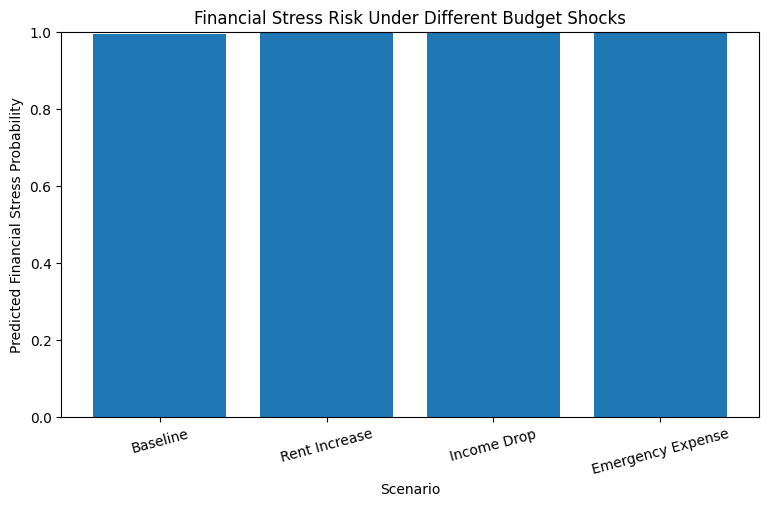

In [ ]:
# Step 19

plt.figure(figsize=(9, 5))
plt.bar(shock_results_df['scenario'], shock_results_df['stress_probability'])
plt.xlabel("Scenario")
plt.ylabel("Predicted Financial Stress Probability")
plt.title("Financial Stress Risk Under Different Budget Shocks")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

In [ ]:
# Step 20

def risk_level(prob):
    if prob < 0.30:
        return "Low"
    elif prob < 0.70:
        return "Medium"
    else:
        return "High"

shock_results_df['risk_level'] = shock_results_df['stress_probability'].apply(risk_level)

print(shock_results_df)

            scenario  stress_probability  predicted_class risk_level
0           Baseline              0.9925                1       High
1      Rent Increase              0.9997                1       High
2        Income Drop              0.9999                1       High
3  Emergency Expense              0.9994                1       High


In [ ]:
# Step 21

detailed_results = []

for s in shock_scenarios:
    total_funds = s['monthly_income'] + s['financial_aid']
    total_spending = (
        s['housing'] + s['food'] + s['transportation'] + s['books_supplies'] +
        s['entertainment'] + s['personal_care'] + s['technology'] +
        s['health_wellness'] + s['miscellaneous']
    )
    leftover_money = total_funds - total_spending

    result = predict_financial_stress(
        monthly_income=s['monthly_income'],
        financial_aid=s['financial_aid'],
        housing=s['housing'],
        food=s['food'],
        transportation=s['transportation'],
        books_supplies=s['books_supplies'],
        entertainment=s['entertainment'],
        personal_care=s['personal_care'],
        technology=s['technology'],
        health_wellness=s['health_wellness'],
        miscellaneous=s['miscellaneous']
    )

    detailed_results.append({
        'scenario': s['scenario'],
        'total_funds': total_funds,
        'total_spending': total_spending,
        'leftover_money': leftover_money,
        'stress_probability': result['stress_probability'],
        'predicted_class': result['predicted_class'],
        'risk_level': risk_level(result['stress_probability'])
    })

detailed_results_df = pd.DataFrame(detailed_results)
print(detailed_results_df)

            scenario  total_funds  total_spending  leftover_money  \
0           Baseline         1500            1820            -320   
1      Rent Increase         1500            2020            -520   
2        Income Drop         1200            1820            -620   
3  Emergency Expense         1500            1980            -480   

   stress_probability  predicted_class risk_level  
0              0.9925                1       High  
1              0.9997                1       High  
2              0.9999                1       High  
3              0.9994                1       High  


In [ ]:
# Step 22

def evaluate_budget_scenario(monthly_income, financial_aid, housing, food, transportation,
                             books_supplies, entertainment, personal_care,
                             technology, health_wellness, miscellaneous):

    total_funds = monthly_income + financial_aid
    total_spending = (
        housing + food + transportation + books_supplies +
        entertainment + personal_care + technology +
        health_wellness + miscellaneous
    )
    leftover_money = total_funds - total_spending

    prediction = predict_financial_stress(
        monthly_income=monthly_income,
        financial_aid=financial_aid,
        housing=housing,
        food=food,
        transportation=transportation,
        books_supplies=books_supplies,
        entertainment=entertainment,
        personal_care=personal_care,
        technology=technology,
        health_wellness=health_wellness,
        miscellaneous=miscellaneous
    )

    return {
        "total_funds": total_funds,
        "total_spending": total_spending,
        "leftover_money": leftover_money,
        "stress_probability": prediction["stress_probability"],
        "predicted_class": prediction["predicted_class"],
        "risk_level": risk_level(prediction["stress_probability"])
    }

print("Scenario evaluation function created successfully.")

Scenario evaluation function created successfully.


In [ ]:
# Step 23

test_result = evaluate_budget_scenario(
    monthly_income=1400,
    financial_aid=250,
    housing=950,
    food=260,
    transportation=100,
    books_supplies=75,
    entertainment=120,
    personal_care=50,
    technology=80,
    health_wellness=60,
    miscellaneous=90
)

for key, value in test_result.items():
    print(f"{key}: {value}")

total_funds: 1650
total_spending: 1785
leftover_money: -135
stress_probability: 0.876
predicted_class: 1
risk_level: High


In [ ]:
# Step 24

scenario_inputs = [
    {
        'scenario': 'Balanced Budget',
        'monthly_income': 1600,
        'financial_aid': 300,
        'housing': 850,
        'food': 240,
        'transportation': 100,
        'books_supplies': 60,
        'entertainment': 100,
        'personal_care': 50,
        'technology': 60,
        'health_wellness': 50,
        'miscellaneous': 80
    },
    {
        'scenario': 'Tight Month',
        'monthly_income': 1300,
        'financial_aid': 200,
        'housing': 950,
        'food': 260,
        'transportation': 120,
        'books_supplies': 70,
        'entertainment': 120,
        'personal_care': 60,
        'technology': 80,
        'health_wellness': 60,
        'miscellaneous': 100
    },
    {
        'scenario': 'Emergency Shock',
        'monthly_income': 1300,
        'financial_aid': 200,
        'housing': 950,
        'food': 260,
        'transportation': 120,
        'books_supplies': 70,
        'entertainment': 120,
        'personal_care': 60,
        'technology': 80,
        'health_wellness': 60,
        'miscellaneous': 300
    }
]

comparison_results = []

for s in scenario_inputs:
    result = evaluate_budget_scenario(
        monthly_income=s['monthly_income'],
        financial_aid=s['financial_aid'],
        housing=s['housing'],
        food=s['food'],
        transportation=s['transportation'],
        books_supplies=s['books_supplies'],
        entertainment=s['entertainment'],
        personal_care=s['personal_care'],
        technology=s['technology'],
        health_wellness=s['health_wellness'],
        miscellaneous=s['miscellaneous']
    )

    comparison_results.append({
        'scenario': s['scenario'],
        'total_funds': result['total_funds'],
        'total_spending': result['total_spending'],
        'leftover_money': result['leftover_money'],
        'stress_probability': result['stress_probability'],
        'risk_level': result['risk_level']
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df)

          scenario  total_funds  total_spending  leftover_money  \
0  Balanced Budget         1900            1590             310   
1      Tight Month         1500            1820            -320   
2  Emergency Shock         1500            2020            -520   

   stress_probability risk_level  
0              0.0060        Low  
1              0.9931       High  
2              0.9997       High  


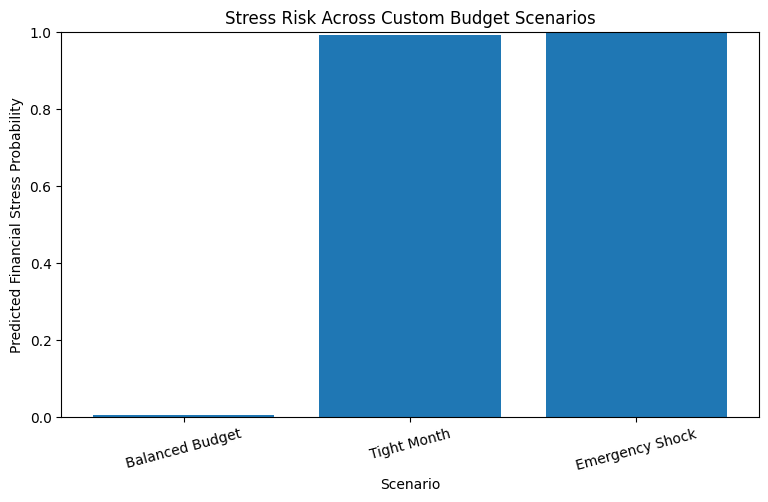

In [ ]:
# Step 25

plt.figure(figsize=(9, 5))
plt.bar(comparison_df['scenario'], comparison_df['stress_probability'])
plt.xlabel("Scenario")
plt.ylabel("Predicted Financial Stress Probability")
plt.title("Stress Risk Across Custom Budget Scenarios")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

In [ ]:
# Step 26

comparison_df_display = comparison_df.copy()

comparison_df_display['total_funds'] = comparison_df_display['total_funds'].map(lambda x: f"${x:,.0f}")
comparison_df_display['total_spending'] = comparison_df_display['total_spending'].map(lambda x: f"${x:,.0f}")
comparison_df_display['leftover_money'] = comparison_df_display['leftover_money'].map(lambda x: f"${x:,.0f}")
comparison_df_display['stress_probability'] = comparison_df_display['stress_probability'].map(lambda x: f"{x:.1%}")

comparison_df_display

,scenario,total_funds,total_spending,leftover_money,stress_probability,risk_level
0,Balanced Budget,"$1,900","$1,590",$310,0.6%,Low
1,Tight Month,"$1,500","$1,820",$-320,99.3%,High
2,Emergency Shock,"$1,500","$2,020",$-520,100.0%,High


In [ ]:
# Step 27

df['stress_score'] = 0

# 1 point if leftover money is negative
df['stress_score'] += (df['leftover_money'] < 0).astype(int)

# 1 point if leftover money is very low even if not negative
df['stress_score'] += (df['leftover_money'] < 100).astype(int)

# 1 point if housing takes more than 50% of total funds
df['stress_score'] += ((df['housing'] / df['total_funds']) > 0.5).astype(int)

# 1 point if entertainment + miscellaneous is relatively high
df['stress_score'] += (((df['entertainment'] + df['miscellaneous']) / df['total_spending']) > 0.25).astype(int)

# Convert score into category
def stress_category(score):
    if score <= 1:
        return "Low"
    elif score == 2:
        return "Medium"
    else:
        return "High"

df['stress_category'] = df['stress_score'].apply(stress_category)

print(df[['leftover_money', 'stress_score', 'stress_category']].head())

print("\nStress category counts:")
print(df['stress_category'].value_counts())

   leftover_money  stress_score stress_category
0            -540             3            High
1              33             1             Low
2             -97             2          Medium
3            -848             3            High
4            -609             3            High

Stress category counts:
stress_category
High      415
Low       294
Medium    291
Name: count, dtype: int64


In [ ]:
# Step 28

df['financial_stress_v2'] = np.where(df['stress_score'] >= 2, 1, 0)

print(df[['stress_score', 'stress_category', 'financial_stress_v2']].head())

print("\nNew target counts:")
print(df['financial_stress_v2'].value_counts())

print("\nNew target percentages:")
print(df['financial_stress_v2'].value_counts(normalize=True) * 100)

   stress_score stress_category  financial_stress_v2
0             3            High                    1
1             1             Low                    0
2             2          Medium                    1
3             3            High                    1
4             3            High                    1

New target counts:
financial_stress_v2
1    706
0    294
Name: count, dtype: int64

New target percentages:
financial_stress_v2
1    70.6
0    29.4
Name: proportion, dtype: float64


In [ ]:
# Step 29

y_v2 = df['financial_stress_v2']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X, y_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_v2
)

scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

model_v2 = LogisticRegression(random_state=42)
model_v2.fit(X_train_v2_scaled, y_train_v2)

print("Updated model trained successfully.")

Updated model trained successfully.


In [ ]:
# Step 30

y_pred_v2 = model_v2.predict(X_test_v2_scaled)
y_prob_v2 = model_v2.predict_proba(X_test_v2_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test_v2, y_pred_v2))
print("ROC AUC:", roc_auc_score(y_test_v2, y_prob_v2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_v2, y_pred_v2))

print("\nClassification Report:")
print(classification_report(y_test_v2, y_pred_v2))

Accuracy: 0.995
ROC AUC: 0.9992787594662821

Confusion Matrix:
[[ 59   0]
 [  1 140]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        59
           1       1.00      0.99      1.00       141

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [ ]:
# Step 31

def predict_financial_stress_v2(monthly_income, financial_aid, housing, food, transportation,
                                books_supplies, entertainment, personal_care,
                                technology, health_wellness, miscellaneous):

    input_data = pd.DataFrame([{
        'monthly_income': monthly_income,
        'financial_aid': financial_aid,
        'housing': housing,
        'food': food,
        'transportation': transportation,
        'books_supplies': books_supplies,
        'entertainment': entertainment,
        'personal_care': personal_care,
        'technology': technology,
        'health_wellness': health_wellness,
        'miscellaneous': miscellaneous
    }])

    input_scaled = scaler_v2.transform(input_data)
    stress_probability = model_v2.predict_proba(input_scaled)[0][1]
    stress_prediction = model_v2.predict(input_scaled)[0]

    return {
        "predicted_class": int(stress_prediction),
        "stress_probability": round(float(stress_probability), 4),
        "risk_level": risk_level(float(stress_probability))
    }

print("Updated simulator function created successfully.")

Updated simulator function created successfully.


In [ ]:
# Step 32

result_v2 = predict_financial_stress_v2(
    monthly_income=1400,
    financial_aid=250,
    housing=950,
    food=260,
    transportation=100,
    books_supplies=75,
    entertainment=120,
    personal_care=50,
    technology=80,
    health_wellness=60,
    miscellaneous=90
)

print(result_v2)

{'predicted_class': 1, 'stress_probability': 0.8905, 'risk_level': 'High'}


In [ ]:
# Step 33

def evaluate_budget_scenario_v2(monthly_income, financial_aid, housing, food, transportation,
                                books_supplies, entertainment, personal_care,
                                technology, health_wellness, miscellaneous):

    total_funds = monthly_income + financial_aid
    total_spending = (
        housing + food + transportation + books_supplies +
        entertainment + personal_care + technology +
        health_wellness + miscellaneous
    )
    leftover_money = total_funds - total_spending

    prediction = predict_financial_stress_v2(
        monthly_income=monthly_income,
        financial_aid=financial_aid,
        housing=housing,
        food=food,
        transportation=transportation,
        books_supplies=books_supplies,
        entertainment=entertainment,
        personal_care=personal_care,
        technology=technology,
        health_wellness=health_wellness,
        miscellaneous=miscellaneous
    )

    return {
        "total_funds": total_funds,
        "total_spending": total_spending,
        "leftover_money": leftover_money,
        "stress_probability": prediction["stress_probability"],
        "predicted_class": prediction["predicted_class"],
        "risk_level": prediction["risk_level"]
    }

print("Final scenario evaluation function created successfully.")

Final scenario evaluation function created successfully.


In [ ]:
# Step 34

final_test = evaluate_budget_scenario_v2(
    monthly_income=1500,
    financial_aid=250,
    housing=1000,
    food=250,
    transportation=120,
    books_supplies=60,
    entertainment=100,
    personal_care=50,
    technology=70,
    health_wellness=60,
    miscellaneous=90
)

for key, value in final_test.items():
    print(f"{key}: {value}")

total_funds: 1750
total_spending: 1800
leftover_money: -50
stress_probability: 0.6864
predicted_class: 1
risk_level: Medium


In [ ]:
# Step 35

user_scenario = {
    "monthly_income": 1500,
    "financial_aid": 250,
    "housing": 1000,
    "food": 250,
    "transportation": 120,
    "books_supplies": 60,
    "entertainment": 100,
    "personal_care": 50,
    "technology": 70,
    "health_wellness": 60,
    "miscellaneous": 90
}

user_result = evaluate_budget_scenario_v2(
    monthly_income=user_scenario["monthly_income"],
    financial_aid=user_scenario["financial_aid"],
    housing=user_scenario["housing"],
    food=user_scenario["food"],
    transportation=user_scenario["transportation"],
    books_supplies=user_scenario["books_supplies"],
    entertainment=user_scenario["entertainment"],
    personal_care=user_scenario["personal_care"],
    technology=user_scenario["technology"],
    health_wellness=user_scenario["health_wellness"],
    miscellaneous=user_scenario["miscellaneous"]
)

print("User Scenario Result:")
for key, value in user_result.items():
    print(f"{key}: {value}")

User Scenario Result:
total_funds: 1750
total_spending: 1800
leftover_money: -50
stress_probability: 0.6864
predicted_class: 1
risk_level: Medium


In [ ]:
# Step 36

total_funds = user_result["total_funds"]
total_spending = user_result["total_spending"]

breakdown_df = pd.DataFrame({
    "category": [
        "Housing", "Food", "Transportation", "Books & Supplies",
        "Entertainment", "Personal Care", "Technology",
        "Health & Wellness", "Miscellaneous"
    ],
    "amount": [
        user_scenario["housing"],
        user_scenario["food"],
        user_scenario["transportation"],
        user_scenario["books_supplies"],
        user_scenario["entertainment"],
        user_scenario["personal_care"],
        user_scenario["technology"],
        user_scenario["health_wellness"],
        user_scenario["miscellaneous"]
    ]
})

breakdown_df["share_of_spending"] = breakdown_df["amount"] / total_spending

print("Budget Breakdown:")
print(breakdown_df)

Budget Breakdown:
            category  amount  share_of_spending
0            Housing    1000           0.555556
1               Food     250           0.138889
2     Transportation     120           0.066667
3   Books & Supplies      60           0.033333
4      Entertainment     100           0.055556
5      Personal Care      50           0.027778
6         Technology      70           0.038889
7  Health & Wellness      60           0.033333
8      Miscellaneous      90           0.050000


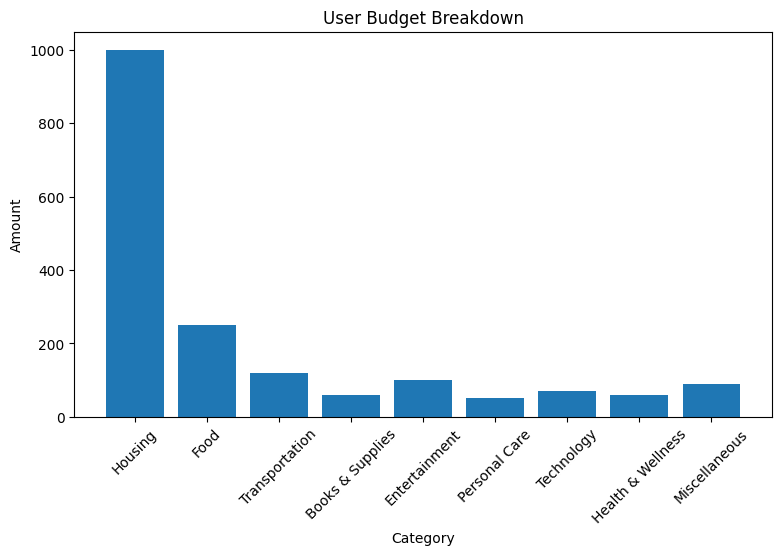

In [ ]:
# Step 37

plt.figure(figsize=(9, 5))
plt.bar(breakdown_df["category"], breakdown_df["amount"])
plt.xlabel("Category")
plt.ylabel("Amount")
plt.title("User Budget Breakdown")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Step 38

breakdown_display = breakdown_df.copy()
breakdown_display["share_of_spending"] = breakdown_display["share_of_spending"] * 100
breakdown_display = breakdown_display.sort_values(by="amount", ascending=False)

breakdown_display["amount"] = breakdown_display["amount"].map(lambda x: f"${x:,.0f}")
breakdown_display["share_of_spending"] = breakdown_display["share_of_spending"].map(lambda x: f"{x:.1f}%")

print("Formatted Budget Breakdown:")
print(breakdown_display)

Formatted Budget Breakdown:
            category  amount share_of_spending
0            Housing  $1,000             55.6%
1               Food    $250             13.9%
2     Transportation    $120              6.7%
4      Entertainment    $100              5.6%
8      Miscellaneous     $90              5.0%
6         Technology     $70              3.9%
3   Books & Supplies     $60              3.3%
7  Health & Wellness     $60              3.3%
5      Personal Care     $50              2.8%


In [ ]:
# Step 39

top_category = breakdown_df.sort_values(by="amount", ascending=False).iloc[0]["category"]
top_amount = breakdown_df.sort_values(by="amount", ascending=False).iloc[0]["amount"]

print("Scenario Insight Summary:\n")

print(f"Your total monthly funds are ${user_result['total_funds']:.0f}.")
print(f"Your total monthly spending is ${user_result['total_spending']:.0f}.")
print(f"Your leftover money is ${user_result['leftover_money']:.0f}.")
print(f"The model predicts a financial stress probability of {user_result['stress_probability']:.1%}, which falls into the {user_result['risk_level']} risk category.")
print(f"Your largest spending category is {top_category} at ${top_amount:.0f}.")

Scenario Insight Summary:

Your total monthly funds are $1750.
Your total monthly spending is $1800.
Your leftover money is $-50.
The model predicts a financial stress probability of 68.6%, which falls into the Medium risk category.
Your largest spending category is Housing at $1000.


In [ ]:
# Step 40

housing_values = [700, 850, 1000, 1150, 1300]
housing_results = []

for h in housing_values:
    result = evaluate_budget_scenario_v2(
        monthly_income=user_scenario["monthly_income"],
        financial_aid=user_scenario["financial_aid"],
        housing=h,
        food=user_scenario["food"],
        transportation=user_scenario["transportation"],
        books_supplies=user_scenario["books_supplies"],
        entertainment=user_scenario["entertainment"],
        personal_care=user_scenario["personal_care"],
        technology=user_scenario["technology"],
        health_wellness=user_scenario["health_wellness"],
        miscellaneous=user_scenario["miscellaneous"]
    )

    housing_results.append({
        "housing": h,
        "leftover_money": result["leftover_money"],
        "stress_probability": result["stress_probability"],
        "risk_level": result["risk_level"]
    })

housing_results_df = pd.DataFrame(housing_results)
print(housing_results_df)

   housing  leftover_money  stress_probability risk_level
0      700             250              0.0162        Low
1      850             100              0.1595        Low
2     1000             -50              0.6864     Medium
3     1150            -200              0.9619       High
4     1300            -350              0.9966       High


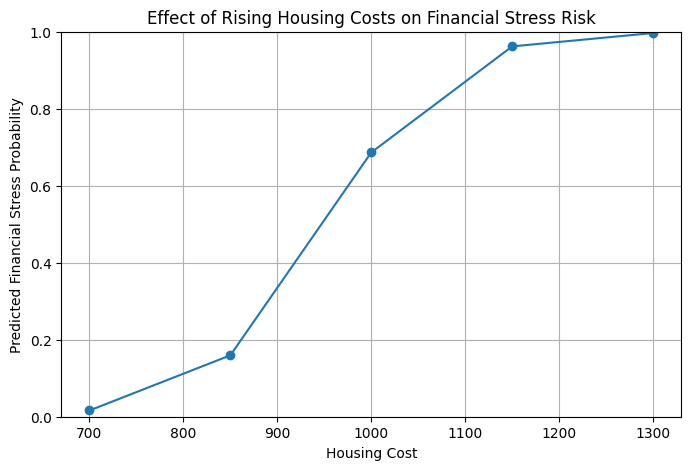

In [ ]:
# Step 41

plt.figure(figsize=(8, 5))
plt.plot(housing_results_df["housing"], housing_results_df["stress_probability"], marker="o")
plt.xlabel("Housing Cost")
plt.ylabel("Predicted Financial Stress Probability")
plt.title("Effect of Rising Housing Costs on Financial Stress Risk")
plt.ylim(0, 1)
plt.grid(True)
plt.show()


In [ ]:
# Step 42

lowest_risk_row = housing_results_df.loc[housing_results_df["stress_probability"].idxmin()]
highest_risk_row = housing_results_df.loc[housing_results_df["stress_probability"].idxmax()]

print("Housing Shock Summary:\n")
print(
    f"When housing is ${lowest_risk_row['housing']:.0f}, "
    f"predicted stress probability is {lowest_risk_row['stress_probability']:.1%} "
    f"with leftover money of ${lowest_risk_row['leftover_money']:.0f}."
)

print(
    f"When housing rises to ${highest_risk_row['housing']:.0f}, "
    f"predicted stress probability increases to {highest_risk_row['stress_probability']:.1%} "
    f"and leftover money changes to ${highest_risk_row['leftover_money']:.0f}."
)

print(
    "This shows how rising housing costs can quickly reduce financial flexibility "
    "and increase the likelihood of financial stress."
)

Housing Shock Summary:

When housing is $700, predicted stress probability is 1.6% with leftover money of $250.
When housing rises to $1300, predicted stress probability increases to 99.7% and leftover money changes to $-350.
This shows how rising housing costs can quickly reduce financial flexibility and increase the likelihood of financial stress.


In [ ]:
# Step 43

shock_comparison = []

# Baseline
baseline = evaluate_budget_scenario_v2(
    monthly_income=user_scenario["monthly_income"],
    financial_aid=user_scenario["financial_aid"],
    housing=user_scenario["housing"],
    food=user_scenario["food"],
    transportation=user_scenario["transportation"],
    books_supplies=user_scenario["books_supplies"],
    entertainment=user_scenario["entertainment"],
    personal_care=user_scenario["personal_care"],
    technology=user_scenario["technology"],
    health_wellness=user_scenario["health_wellness"],
    miscellaneous=user_scenario["miscellaneous"]
)

shock_comparison.append({
    "scenario": "Baseline",
    "leftover_money": baseline["leftover_money"],
    "stress_probability": baseline["stress_probability"],
    "risk_level": baseline["risk_level"]
})

# Rent increase
rent_shock = evaluate_budget_scenario_v2(
    monthly_income=user_scenario["monthly_income"],
    financial_aid=user_scenario["financial_aid"],
    housing=user_scenario["housing"] + 200,
    food=user_scenario["food"],
    transportation=user_scenario["transportation"],
    books_supplies=user_scenario["books_supplies"],
    entertainment=user_scenario["entertainment"],
    personal_care=user_scenario["personal_care"],
    technology=user_scenario["technology"],
    health_wellness=user_scenario["health_wellness"],
    miscellaneous=user_scenario["miscellaneous"]
)

shock_comparison.append({
    "scenario": "Rent +$200",
    "leftover_money": rent_shock["leftover_money"],
    "stress_probability": rent_shock["stress_probability"],
    "risk_level": rent_shock["risk_level"]
})

# Income drop
income_shock = evaluate_budget_scenario_v2(
    monthly_income=user_scenario["monthly_income"] - 300,
    financial_aid=user_scenario["financial_aid"],
    housing=user_scenario["housing"],
    food=user_scenario["food"],
    transportation=user_scenario["transportation"],
    books_supplies=user_scenario["books_supplies"],
    entertainment=user_scenario["entertainment"],
    personal_care=user_scenario["personal_care"],
    technology=user_scenario["technology"],
    health_wellness=user_scenario["health_wellness"],
    miscellaneous=user_scenario["miscellaneous"]
)

shock_comparison.append({
    "scenario": "Income -$300",
    "leftover_money": income_shock["leftover_money"],
    "stress_probability": income_shock["stress_probability"],
    "risk_level": income_shock["risk_level"]
})

# Emergency expense
emergency_shock = evaluate_budget_scenario_v2(
    monthly_income=user_scenario["monthly_income"],
    financial_aid=user_scenario["financial_aid"],
    housing=user_scenario["housing"],
    food=user_scenario["food"],
    transportation=user_scenario["transportation"],
    books_supplies=user_scenario["books_supplies"],
    entertainment=user_scenario["entertainment"],
    personal_care=user_scenario["personal_care"],
    technology=user_scenario["technology"],
    health_wellness=user_scenario["health_wellness"],
    miscellaneous=user_scenario["miscellaneous"] + 200
)

shock_comparison.append({
    "scenario": "Emergency +$200",
    "leftover_money": emergency_shock["leftover_money"],
    "stress_probability": emergency_shock["stress_probability"],
    "risk_level": emergency_shock["risk_level"]
})

shock_comparison_df = pd.DataFrame(shock_comparison)
print(shock_comparison_df)

          scenario  leftover_money  stress_probability risk_level
0         Baseline             -50              0.6864     Medium
1       Rent +$200            -250              0.9828       High
2     Income -$300            -350              0.9968       High
3  Emergency +$200            -250              0.9842       High


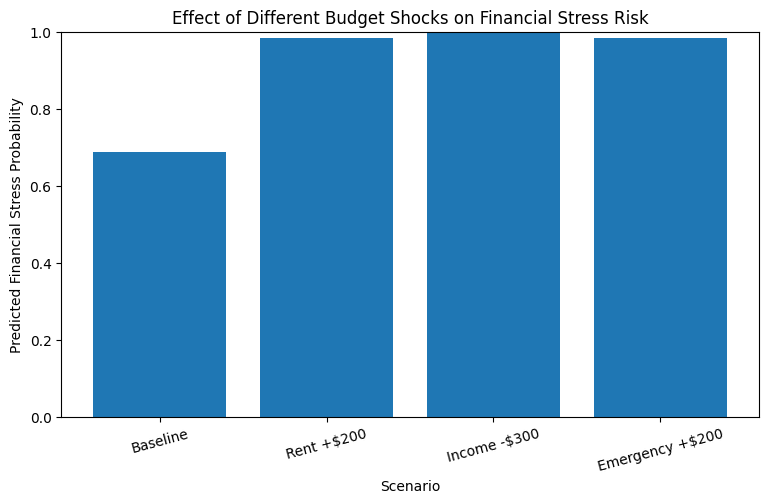

In [ ]:
# Step 44

plt.figure(figsize=(9, 5))
plt.bar(shock_comparison_df["scenario"], shock_comparison_df["stress_probability"])
plt.xlabel("Scenario")
plt.ylabel("Predicted Financial Stress Probability")
plt.title("Effect of Different Budget Shocks on Financial Stress Risk")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

In [ ]:
# Step 45

baseline_leftover = shock_comparison_df.loc[
    shock_comparison_df["scenario"] == "Baseline", "leftover_money"
].values[0]

baseline_prob = shock_comparison_df.loc[
    shock_comparison_df["scenario"] == "Baseline", "stress_probability"
].values[0]

shock_comparison_df["change_in_leftover"] = shock_comparison_df["leftover_money"] - baseline_leftover
shock_comparison_df["change_in_stress_probability"] = shock_comparison_df["stress_probability"] - baseline_prob

print(shock_comparison_df)

          scenario  leftover_money  stress_probability risk_level  \
0         Baseline             -50              0.6864     Medium   
1       Rent +$200            -250              0.9828       High   
2     Income -$300            -350              0.9968       High   
3  Emergency +$200            -250              0.9842       High   

   change_in_leftover  change_in_stress_probability  
0                   0                        0.0000  
1                -200                        0.2964  
2                -300                        0.3104  
3                -200                        0.2978  


In [ ]:
# Step 46

shock_display = shock_comparison_df.copy()

shock_display["leftover_money"] = shock_display["leftover_money"].map(lambda x: f"${x:,.0f}")
shock_display["stress_probability"] = shock_display["stress_probability"].map(lambda x: f"{x:.1%}")
shock_display["change_in_leftover"] = shock_display["change_in_leftover"].map(lambda x: f"${x:,.0f}")
shock_display["change_in_stress_probability"] = shock_display["change_in_stress_probability"].map(lambda x: f"{x:.1%}")

shock_display

,scenario,leftover_money,stress_probability,risk_level,change_in_leftover,change_in_stress_probability
0,Baseline,$-50,68.6%,Medium,$0,0.0%
1,Rent +$200,$-250,98.3%,High,$-200,29.6%
2,Income -$300,$-350,99.7%,High,$-300,31.0%
3,Emergency +$200,$-250,98.4%,High,$-200,29.8%


In [ ]:
# Step 47

non_baseline_shocks = shock_comparison_df[shock_comparison_df["scenario"] != "Baseline"].copy()

worst_shock = non_baseline_shocks.loc[
    non_baseline_shocks["stress_probability"].idxmax()
]

print("Shock Comparison Summary:\n")
print(
    f"The baseline scenario has leftover money of ${baseline_leftover:.0f} "
    f"and a predicted financial stress probability of {baseline_prob:.1%}."
)

print(
    f"The most damaging shock in this comparison is {worst_shock['scenario']}, "
    f"which changes leftover money to ${worst_shock['leftover_money']:.0f} "
    f"and raises predicted stress probability to {worst_shock['stress_probability']:.1%}."
)

print(
    f"Compared to the baseline, this shock changes leftover money by "
    f"${worst_shock['change_in_leftover']:.0f} and changes stress probability by "
    f"{worst_shock['change_in_stress_probability']:.1%}."
)

Shock Comparison Summary:

The baseline scenario has leftover money of $-50 and a predicted financial stress probability of 68.6%.
The most damaging shock in this comparison is Income -$300, which changes leftover money to $-350 and raises predicted stress probability to 99.7%.
Compared to the baseline, this shock changes leftover money by $-300 and changes stress probability by 31.0%.


In [ ]:
# Step 48

final_summary = pd.DataFrame([
    {
        "metric": "Baseline Leftover Money",
        "value": f"${baseline_leftover:,.0f}"
    },
    {
        "metric": "Baseline Stress Probability",
        "value": f"{baseline_prob:.1%}"
    },
    {
        "metric": "Highest-Risk Shock",
        "value": worst_shock["scenario"]
    },
    {
        "metric": "Worst Shock Leftover Money",
        "value": f"${worst_shock['leftover_money']:,.0f}"
    },
    {
        "metric": "Worst Shock Stress Probability",
        "value": f"{worst_shock['stress_probability']:.1%}"
    },
    {
        "metric": "Worst Shock Risk Level",
        "value": worst_shock["risk_level"]
    }
])

final_summary

,metric,value
0,Baseline Leftover Money,$-50
1,Baseline Stress Probability,68.6%
2,Highest-Risk Shock,Income -$300
3,Worst Shock Leftover Money,$-350
4,Worst Shock Stress Probability,99.7%
5,Worst Shock Risk Level,High


In [ ]:
# Step 49

comparison_df.to_csv("comparison_results.csv", index=False)
shock_comparison_df.to_csv("shock_comparison_results.csv", index=False)
final_summary.to_csv("final_summary.csv", index=False)

print("Files saved successfully:")
print("- comparison_results.csv")
print("- shock_comparison_results.csv")
print("- final_summary.csv")

Files saved successfully:
- comparison_results.csv
- shock_comparison_results.csv
- final_summary.csv


In [ ]:
# Step 50

import joblib

joblib.dump(model_v2, "budget_stress_model.pkl")
joblib.dump(scaler_v2, "budget_stress_scaler.pkl")

print("Saved successfully:")
print("- budget_stress_model.pkl")
print("- budget_stress_scaler.pkl")

Saved successfully:
- budget_stress_model.pkl
- budget_stress_scaler.pkl


In [ ]:
# Step 51

!ls

 budget_stress_model.pkl    sample_data
 budget_stress_scaler.pkl   shock_comparison_results.csv
 comparison_results.csv    'student_spending (1).csv'
 final_summary.csv


In [ ]:
from google.colab import files

files.download("budget_stress_model.pkl")
files.download("budget_stress_scaler.pkl")
files.download("comparison_results.csv")
files.download("shock_comparison_results.csv")
files.download("final_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>